In [1]:
!pip install tf-levenberg-marquardt 

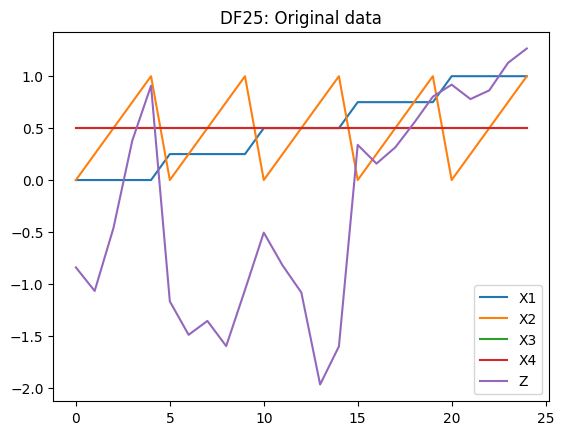

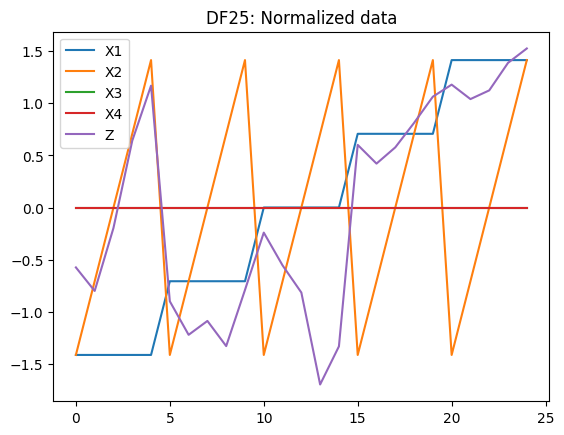

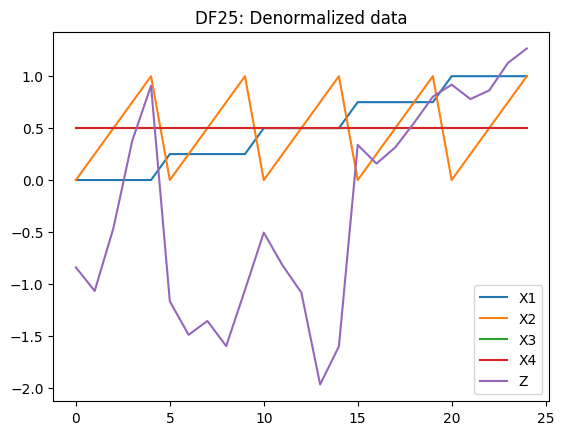

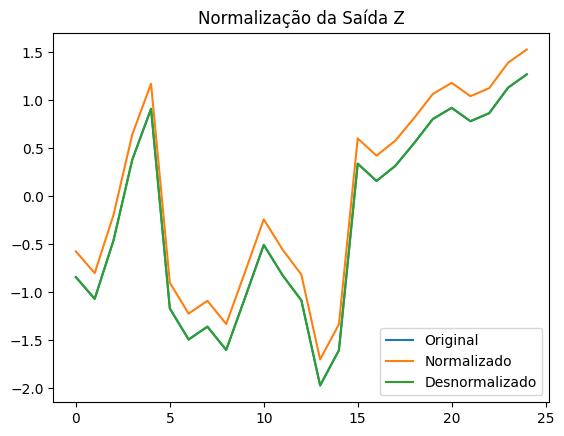

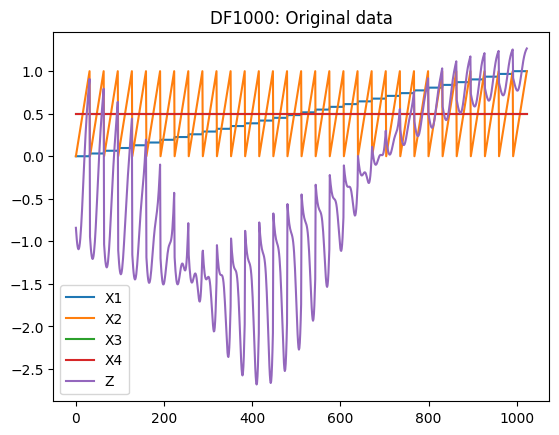

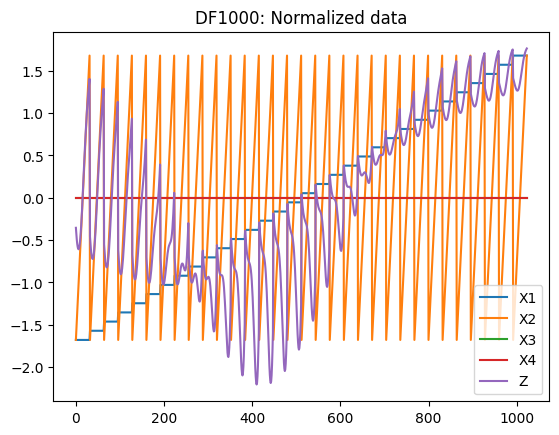

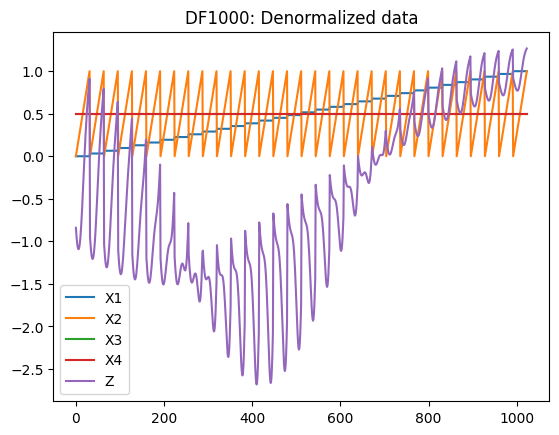

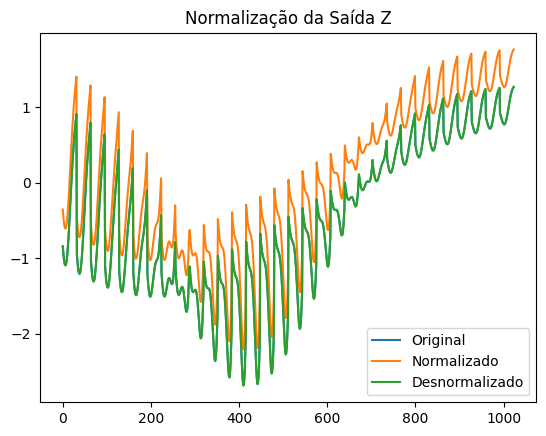

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Escaladores globais
scaler = StandardScaler()
out_scaler = StandardScaler()

# Função Hartmann4
def function(x):
    alpha = np.array([1.0, 1.2, 3.0, 3.2])

    A = np.array([
        [10,   3, 17, 3.5],
        [0.05, 10, 17, 0.1],
        [3, 3.5, 1.7, 10],
        [17,   8, 0.05, 10]
    ])

    P = 1e-4 * np.array([
        [1312, 1696, 5569, 124],
        [2329, 4135, 8307, 3736],
        [2348, 1451, 3522, 2883],
        [4047, 8828, 8732, 5743]
    ])

    x = np.asarray(x)
    if np.any((x < 0) | (x > 1)):
        raise ValueError("Todos os valores de x devem estar no intervalo [0, 1].")

    diff = x - P
    exp_term = np.exp(-np.sum(A * diff**2, axis=1))
    z = (1.1 - np.dot(alpha, exp_term)) / 0.839

    x1, x2, x3, x4 = x
    return z, x1, x2, x3, x4

# Criação do DataFrame com grid 2D (x1, x2), fixando x3, x4
def create_dataframe(grid, x3=0.5, x4=0.5):
    x_vals = np.linspace(0, 1, grid)
    data = []

    for x1 in x_vals:
        for x2 in x_vals:
            z, x1, x2, x3_val, x4_val = function([x1, x2, x3, x4])
            data.append([x1, x2, x3_val, x4_val, z])

    df = pd.DataFrame(data, columns=["X1", "X2", "X3", "X4", "Z"])
    return df

# Visualização da normalização
def show_norm(df, label="function", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if plot:
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
        plt.show()
    return df_norm

# Visualizar normalização da saída Z
def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)
    plt.figure()
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='Desnormalizado')
    plt.title("Normalização da Saída Z")
    plt.legend()
    plt.show()

# Execução dos testes
df_25 = create_dataframe(grid=5)
df_25_norm = show_norm(df_25, label="DF25", plot=True)
test_out_scaler(df_25)

df_1000 = create_dataframe(grid=32)
df_1000_norm = show_norm(df_1000, label="DF1000", plot=True)
test_out_scaler(df_1000)




In [3]:
def split_df(df):
    _input = np.vstack([df['X1'], df['X2'], df['X3'], df['X4']]).T
    _output = np.array(df['Z'])
    return (_input, _output)


In [4]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
            loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model


2025-06-24 18:36:09.853953: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-24 18:36:09.919329: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-24 18:36:09.919367: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-24 18:36:09.920562: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-24 18:36:09.926453: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-24 18:36:09.927200: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [5]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.cast(input, tf.float32)  # Mantém shape (N, 4)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)  # Output vira (N, 1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)
 
    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [6]:
import pickle
from itertools import product

class Tester:
  def __init__(self, run_times=500, dataset_run_times=10):
    self.run_times = run_times
    self.better_metrics = {}
    self.dataset_run_times = dataset_run_times
    self.input_25, self.output_25 = split_df(df_25_norm)
    self.input_1000, self.output_1000 = split_df(df_1000_norm)
  
  def setArchitecure(self, trainer, _hidden_sizes, _pg, _lr):
    shuffler = ShuffleArchitecture(input_size=4,
                                    hidden_sizes=_hidden_sizes,
                                    output_size=1,
                                    act_h='tanh',
                                    act_o='linear',
                                    param_reg=_pg)
    shuffler.set_architecture()    
    trainer.lm_model = shuffler.create_model(_lr)
    trainer.k = shuffler.compute_k()

  def Train(self, trainer, epochs=1000):
    trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
    return(trainer.get_metrics(), trainer.lm_model)

  def SaveModelWeights(self, model, fileName):
    path = f"content/models/{fileName}.keras"
    open(path,'w').close()
    model.save_weights(path)

  def SaveDataset(self, trainer, fileName):
    path = f"content/dataset/{fileName}.pkl" 
    with open(path, 'wb') as f:
      pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)
      
  def LoopWeights(self, sort_by, boundarie, trainer, idx):
    better_model = 0
    save = False

    for i in range(self.run_times):
      print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
      metrics, model = self.Train(trainer)
      if (metrics[sort_by] <= boundarie): # should be >= to acsending metrics
        fileName = f"model_{idx}_{better_model}"
        self.SaveModelWeights(model, fileName)
        self.better_metrics[fileName] = metrics
        better_model += 1
        save = True
    return(save)

  def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
    trainer = TrainWithSmallDataset()

    for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
      header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
      print(f"Testando combinacao{count}: {header}")
      self.setArchitecure(trainer, hidden_size, reg, lr)
      for j in range(self.dataset_run_times):
        trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
        if (self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}") == True):
          self.SaveDataset(trainer, f"dataset_{count}_{j}")
          self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
        self.better_metrics = {}

  def DisplayBetterResults(self, sort_by, header, dataset=0):
    df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
    df = df.sort_values([sort_by])
    display(df)
    path = f'content/results/metrics_{dataset}'
    df.to_excel(f"{path}.xlsx", index=True)
    print(f"DataFrame salvo em {path}")
    with open(f"{path}.txt", 'w') as arquivo:
      arquivo.write(header)

# Treinando com 25 dados


In [7]:
tester = Tester(run_times=25, dataset_run_times=10)
tester.Loop(sort_by='mse',
            boundarie = 0.02,
            hidden_sizes = [[8, 4], [8, 6], [7, 8], [6, 8], [9, 5], [7, 9], [9, 5]],
            regularizers=[0.5, 0.03],
            learning_rate=[0.1, 0.05])

Testando combinacao1: Hidden Size=[8, 4], regularizer=0.5, learning_rate=0.1
+++++++++++ [1_0] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 2 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_3_3,0.988385,0.945670,0.995632,0.969908,0.989822,0.011516,0.053864,0.004108,0.014048,0.009078,0.169417,0.107311,1.004891,0.111879,170.928097,269.657039
model_1_3_4,0.989661,0.945517,0.995255,0.965318,0.988422,0.010250,0.054017,0.004463,0.016191,0.010327,0.166171,0.101244,1.004353,0.105555,171.160868,269.889810
model_1_3_2,0.986599,0.945358,0.995846,0.973472,0.990868,0.013286,0.054174,0.003907,0.012384,0.008145,0.173325,0.115264,1.005642,0.120171,170.642127,269.371069
model_1_3_5,0.990544,0.945048,0.994744,0.960119,0.986792,0.009375,0.054481,0.004943,0.018617,0.011780,0.163298,0.096822,1.003981,0.100944,171.339515,270.068457
model_1_3_6,0.991126,0.944372,0.994131,0.954604,0.985025,0.008798,0.055151,0.005520,0.021192,0.013356,0.160748,0.093799,1.003737,0.097792,171.466417,270.195359
model_1_3_1,0.984151,0.944359,0.995860,0.975402,0.991380,0.015713,0.055165,0.003893,0.011483,0.007688,0.177935,0.125351,1.006673,0.130687,170.306559,269.035501
model_1_3_7,0.991476,0.943567,0.993443,0.948973,0.983189,0.008451,0.055950,0.006167,0.023821,0.014994,0.158482,0.091930,1.003589,0.095844,171.546890,270.275832
model_1_3_8,0.991650,0.942688,0.992707,0.943366,0.981334,0.008278,0.056822,0.006858,0.026438,0.016648,0.156464,0.090985,1.003516,0.094858,171.588249,270.317191
model_1_3_0,0.980835,0.942338,0.995615,0.974817,0.991098,0.019001,0.057168,0.004124,0.011756,0.007940,0.183408,0.137844,1.008070,0.143712,169.926530,268.655472
model_1_3_9,0.991693,0.941775,0.991947,0.937877,0.979497,0.008236,0.057727,0.007573,0.029001,0.018287,0.154663,0.090752,1.003498,0.094615,171.598515,270.327456


DataFrame salvo em content/results/metrics_1_3
+++++++++++ [1_4] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_4] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_4] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_4] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_4] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_4] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_4] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_4] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_4] | 9 +++++++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_4_24,0.996579,0.947590,0.992795,0.959737,0.980035,0.003392,0.051961,0.000728,0.020376,0.010552,0.099390,0.058242,1.001441,0.060722,173.372590,272.101532
model_1_4_23,0.996539,0.947476,0.992828,0.959296,0.979827,0.003431,0.052074,0.000725,0.020599,0.010662,0.099979,0.058574,1.001457,0.061068,173.349842,272.078783
model_1_4_22,0.996495,0.947349,0.992865,0.958803,0.979595,0.003475,0.052200,0.000721,0.020849,0.010785,0.100630,0.058947,1.001476,0.061457,173.324464,272.053406
model_1_4_21,0.996445,0.947207,0.992904,0.958252,0.979335,0.003524,0.052341,0.000717,0.021128,0.010922,0.101349,0.059365,1.001497,0.061893,173.296181,272.025123
model_1_4_20,0.996389,0.947049,0.992947,0.957636,0.979044,0.003580,0.052498,0.000713,0.021439,0.011076,0.102143,0.059835,1.001520,0.062382,173.264652,271.993594
model_1_4_19,0.996325,0.946872,0.992993,0.956947,0.978718,0.003644,0.052673,0.000708,0.021788,0.011248,0.103019,0.060363,1.001547,0.062933,173.229520,271.958462
model_1_4_18,0.996252,0.946675,0.993044,0.956176,0.978354,0.003716,0.052868,0.000703,0.022178,0.011441,0.103985,0.060957,1.001578,0.063552,173.190375,271.919317
model_1_4_17,0.996170,0.946455,0.993097,0.955312,0.977945,0.003798,0.053086,0.000698,0.022615,0.011657,0.105049,0.061624,1.001613,0.064248,173.146787,271.875729
model_1_4_16,0.996076,0.946209,0.993155,0.954345,0.977488,0.003891,0.053330,0.000692,0.023105,0.011898,0.106221,0.062376,1.001652,0.065031,173.098303,271.827245
model_1_4_15,0.995968,0.945935,0.993216,0.953261,0.976975,0.003997,0.053602,0.000686,0.023653,0.012170,0.107509,0.063222,1.001697,0.065914,173.044410,271.773352


DataFrame salvo em content/results/metrics_1_4
+++++++++++ [1_5] | 1 ++++++++++++++++++
Stopped at epoch:  109
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_5] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_5] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_5] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_5] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_5] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_5] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_5] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_5] | 9 +++++++++

...

DataFrame salvo em content/results/metrics_27_7
+++++++++++ [27_8] | 1 ++++++++++++++++++
Stopped at epoch:  18
32/32 [==============================] - 0s 2ms/step
+++++++++++ [27_8] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [27_8] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [27_8] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [27_8] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [27_8] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [27_8] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [27_8] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [27_8] | 9 

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_27_8_0,0.998509,0.958524,0.992795,0.994471,0.994222,0.001478,0.041121,0.004514,0.003629,0.004072,0.078830,0.038448,1.000465,0.040085,215.033774,338.140232
model_27_8_1,0.998591,0.958474,0.993261,0.994486,0.994436,0.001397,0.041170,0.004223,0.003619,0.003921,0.080421,0.037372,1.000439,0.038963,215.147371,338.253829
model_27_8_2,0.998658,0.958421,0.993647,0.994488,0.994608,0.001331,0.041223,0.003981,0.003618,0.003799,0.081838,0.036480,1.000418,0.038033,215.243945,338.350403
model_27_8_3,0.998711,0.958368,0.993968,0.994479,0.994747,0.001278,0.041276,0.003780,0.003623,0.003702,0.083101,0.035745,1.000402,0.037266,215.325419,338.431878
model_27_8_4,0.998755,0.958314,0.994235,0.994464,0.994859,0.001235,0.041329,0.003613,0.003634,0.003623,0.084228,0.035140,1.000388,0.036636,215.393673,338.500131
model_27_8_5,0.998789,0.958262,0.994458,0.994444,0.994948,0.001200,0.041380,0.003472,0.003647,0.003560,0.085233,0.034644,1.000377,0.036119,215.450527,338.556985
model_27_8_6,0.998818,0.958212,0.994646,0.994420,0.995021,0.001172,0.041430,0.003355,0.003662,0.003509,0.086131,0.034238,1.000369,0.035696,215.497642,338.604101
model_27_8_7,0.998840,0.958165,0.994804,0.994395,0.995079,0.001150,0.041477,0.003256,0.003679,0.003468,0.086932,0.033907,1.000361,0.035351,215.536513,338.642972
model_27_8_8,0.998859,0.958120,0.994937,0.994368,0.995126,0.001131,0.041521,0.003172,0.003696,0.003434,0.087648,0.033637,1.000356,0.035069,215.568486,338.674944
model_27_8_9,0.998874,0.958078,0.995050,0.994342,0.995164,0.001117,0.041563,0.003102,0.003714,0.003408,0.088288,0.033418,1.000351,0.034840,215.594698,338.701156


DataFrame salvo em content/results/metrics_27_8
+++++++++++ [27_9] | 1 ++++++++++++++++++
Stopped at epoch:  31
32/32 [==============================] - 0s 2ms/step
+++++++++++ [27_9] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [27_9] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [27_9] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [27_9] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [27_9] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [27_9] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [27_9] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [27_9] | 9 

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_27_9_0,0.999373,0.954061,0.993377,0.995346,0.995403,0.000622,0.045546,0.003302,0.000564,0.001933,0.033116,0.024934,1.000195,0.025995,216.766092,339.872551
model_27_9_1,0.999367,0.954027,0.993315,0.995256,0.995353,0.000628,0.045579,0.003333,0.000575,0.001954,0.033104,0.025056,1.000197,0.026123,216.746499,339.852957
model_27_9_2,0.999361,0.953997,0.993258,0.995174,0.995308,0.000633,0.045609,0.003362,0.000585,0.001973,0.033094,0.025168,1.000199,0.026240,216.728696,339.835155
model_27_9_3,0.999356,0.953969,0.993207,0.995100,0.995267,0.000639,0.045636,0.003387,0.000594,0.001990,0.033085,0.025270,1.000201,0.026346,216.712546,339.819004
model_27_9_4,0.999351,0.953945,0.993161,0.995032,0.995230,0.000643,0.045661,0.003410,0.000602,0.002006,0.033077,0.025363,1.000202,0.026442,216.697902,339.804360
model_27_9_5,0.999347,0.953922,0.993119,0.994970,0.995196,0.000648,0.045683,0.003431,0.000609,0.002020,0.033069,0.025447,1.000204,0.026530,216.684630,339.791088
model_27_9_6,0.999343,0.953902,0.993081,0.994914,0.995166,0.000651,0.045703,0.003450,0.000616,0.002033,0.033063,0.025523,1.000205,0.026610,216.672633,339.779091
model_27_9_7,0.999339,0.953884,0.993047,0.994864,0.995138,0.000655,0.045721,0.003467,0.000622,0.002045,0.033057,0.025593,1.000206,0.026682,216.661758,339.768217
model_27_9_8,0.999336,0.953868,0.993016,0.994818,0.995113,0.000658,0.045737,0.003482,0.000628,0.002055,0.033051,0.025656,1.000207,0.026748,216.651953,339.758411
model_27_9_9,0.999333,0.953853,0.992988,0.994776,0.995091,0.000661,0.045752,0.003496,0.000633,0.002065,0.033046,0.025713,1.000208,0.026807,216.643089,339.749547


DataFrame salvo em content/results/metrics_27_9
Testando combinacao28: Hidden Size=[9, 5], regularizer=0.03, learning_rate=0.05
+++++++++++ [28_0] | 1 ++++++++++++++++++
Stopped at epoch:  252
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_0] | 2 ++++++++++++++++++
Stopped at epoch:  22
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_0] | 3 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_0] | 4 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_0] | 5 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_0] | 6 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_0] | 7 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 4ms/step
+++++++++++ [28_0] | 8 ++++++++++++++++++
Stopped at epoc